In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Load and concatenate

Reads the separate sales files for 2025 and 2026 and stacks them on top of each other into a single, combined dataset (`sales_fruit`). 

The output will show a summary of the combined dataset. Check the total number of entries (rows) and look at the "Dtype" column to ensure numbers are recognized as floats/integers and text is recognized as objects/strings.

In [4]:
sales_fruit_2025 = pd.read_csv("sales_fruit_2025.csv", dtype={"APN": "string"})
sales_fruit_2026 = pd.read_csv("sales_fruit_2026.csv", dtype={"APN": "string"})
sales_fruit = pd.concat([sales_fruit_2025, sales_fruit_2026], ignore_index=True)

sales_fruit.info()

<class 'pandas.DataFrame'>
RangeIndex: 17052 entries, 0 to 17051
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 17052 non-null  str    
 1   Store Name           17052 non-null  str    
 2   Department Name      17052 non-null  str    
 3   Department Sort      17052 non-null  int64  
 4   APN                  16956 non-null  string 
 5   Name                 17052 non-null  str    
 6   Sub Department Name  16956 non-null  str    
 7   Sales Inc GST        17052 non-null  float64
 8   Cost Ex GST          17052 non-null  float64
 9   Cost Inc GST         17052 non-null  float64
 10  GP %                 17052 non-null  float64
 11  Lines                17052 non-null  int64  
 12  GP $                 17052 non-null  float64
 13  Quantity             17052 non-null  float64
 14  Sales Ex GST         17052 non-null  float64
 15  Store Sales Ex       17052 non-null  float64
 1

## Data Validation (Counts, Duplicates, and Missing Values)

Checks the health of the data. It verifies that no rows were lost during the merge, looks for accidentally duplicated records, and counts missing values (nulls) in critical columns like APN (barcode) and Sub Department. 

* **Rows:** The combined row count should perfectly match the sum of the individual years.
* **Duplicates:** If there are many duplicates, the raw data may have been exported twice.
* **Nulls:** High numbers of missing APNs or Sub Departments mean we might need to clean the data before digging deeper, as missing categories can skew our totals.

In [5]:
n25, n26 = len(sales_fruit_2025), len(sales_fruit_2026)
assert len(sales_fruit) == n25 + n26, (len(sales_fruit), n25 + n26)
print(f"Rows 2025: {n25}, 2026: {n26}, combined: {len(sales_fruit)}")

sales_fruit["Date"] = pd.to_datetime(sales_fruit["Date"])
sales_fruit["year"] = sales_fruit["Date"].dt.year
sales_fruit["year_month"] = sales_fruit["Date"].dt.to_period("M")

print("Full-row duplicates:", sales_fruit.duplicated().sum())
print("Duplicates on (Date, APN, Name):", sales_fruit.duplicated(subset=["Date", "APN", "Name"]).sum())

null_apn = sales_fruit["APN"].isna()
null_sub = sales_fruit["Sub Department Name"].isna()
print("\nNull counts:\n", sales_fruit[["APN", "Sub Department Name"]].isna().sum())
print("Both APN and Sub Department null:", (null_apn & null_sub).sum())

display(sales_fruit.loc[null_apn | null_sub, ["Date", "APN", "Name", "Sub Department Name"]].head(15))

# Store columns: only useful if they vary within a day
for col in ["Store Sales Ex", "Store Sales Inc"]:
    nu = sales_fruit.groupby("Date")[col].nunique()
    print(f"{col}: dates with >1 distinct value: {(nu > 1).sum()} / {len(nu)} days")

sales_fruit.head()

Rows 2025: 10000, 2026: 7052, combined: 17052
Full-row duplicates: 0
Duplicates on (Date, APN, Name): 0

Null counts:
 APN                    96
Sub Department Name    96
dtype: int64
Both APN and Sub Department null: 96


,Date,APN,Name,Sub Department Name
48,2025-01-02,<NA>,FRUIT AND VEG,NaN
134,2025-01-03,<NA>,FRUIT AND VEG,NaN
425,2025-01-06,<NA>,FRUIT AND VEG,NaN
572,2025-01-08,<NA>,FRUIT AND VEG,NaN
652,2025-01-09,<NA>,FRUIT AND VEG,NaN
794,2025-01-10,<NA>,FRUIT AND VEG,NaN
916,2025-01-11,<NA>,FRUIT AND VEG,NaN
933,2025-01-13,<NA>,FRUIT AND VEG,NaN
1134,2025-01-15,<NA>,FRUIT AND VEG,NaN
1257,2025-01-16,<NA>,FRUIT AND VEG,NaN


Store Sales Ex: dates with >1 distinct value: 164 / 164 days
Store Sales Inc: dates with >1 distinct value: 164 / 164 days


,Date,Store Name,Department Name,Department Sort,APN,Name,Sub Department Name,Sales Inc GST,Cost Ex GST,Cost Inc GST,GP %,Lines,GP $,Quantity,Sales Ex GST,Store Sales Ex,Store Sales Inc,year,year_month
0,2025-01-02,Foodland Wudinna,FRUIT & VEG,5,9369999052256,SWEET CORN PRE PACK 500GMS,Vegetables,5.99,3.5,3.5,41.57,1,2.49,1.0,5.99,5.99,5.99,2025,2025-01
1,2025-01-02,Foodland Wudinna,FRUIT & VEG,5,93536240,BLUEBERRIES 125G,Fruit,119.70,109.5,109.5,8.52,30,10.20,30.0,119.70,119.70,119.70,2025,2025-01
2,2025-01-02,Foodland Wudinna,FRUIT & VEG,5,9339562011836,LK POTATO SALAD 800G,Salads,23.97,15.3,15.3,36.17,3,8.67,3.0,23.97,23.97,23.97,2025,2025-01
3,2025-01-02,Foodland Wudinna,FRUIT & VEG,5,9339562011843,LK COLESLAW SALAD 800G,Salads,15.98,10.2,10.2,36.17,2,5.78,2.0,15.98,15.98,15.98,2025,2025-01
4,2025-01-02,Foodland Wudinna,FRUIT & VEG,5,9340187000037,CUCUMBER BABY LEBANESE P/PACK 250GMS,Vegetables,39.90,28.5,28.5,28.57,10,11.40,10.0,39.90,39.90,39.90,2025,2025-01


## Descriptive Analysis & Date Range Validation

**What this does:** Before diving into specific product performance, this cell performs a broad "health check" on the entire dataset. It verifies the exact date ranges we are working with (confirming the Jan-Apr timeframe for 2025 and 2026). It also generates a statistical summary of our numbers (like average sales and profit) and a quick overview of our text columns (like how many unique products we sell).

**How to interpret:** * **Date Range:** Make sure "First Sale" and "Last Sale" align with your expectations (e.g., stopping in late April) and that "Total Days" looks right for a 4-month period.
* **Numerical Summary:** Look at the `mean` (average) and `max` values. For example, the `max` for Quantity will show you the largest single bulk purchase made in this timeframe. If `min` GP % is highly negative, it confirms we have items selling at a loss.
* **Categorical Summary:** This tells you the breadth of your store. "Unique values" under 'Name' tells you exactly how many distinct products were rung up at the register during this period.

### Date Range Validation

In [45]:
print("--- 📅 Date Range Validation ---")
date_summary = sales_fruit.groupby('year')['Date'].agg(['min', 'max', 'nunique'])
date_summary.columns = ['First Sale Date', 'Last Sale Date', 'Total Active Days']
date_summary['First Sale Date'] = date_summary['First Sale Date'].dt.date
date_summary['Last Sale Date'] = date_summary['Last Sale Date'].dt.date
display(date_summary)

--- 📅 Date Range Validation ---


,First Sale Date,Last Sale Date,Total Active Days
year,,,
2025,2025-01-02,2025-04-30,98
2026,2026-01-01,2026-03-19,66


### Numerical Data Summary

In [ ]:
print("\n--- 📊 Numerical Columns Summary ---")
# Focus on the core numeric columns
num_cols = ['Quantity', 'Sales Ex GST', 'Cost Inc GST', 'GP $', 'GP %', 'Lines']
num_cols_exist = [c for c in num_cols if c in sales_fruit.columns]

# Generate standard descriptive statistics and round to 2 decimals for readability
num_summary = sales_fruit[num_cols_exist].describe().round(2)
display(num_summary)


--- 📊 Numerical Columns Summary ---


,Quantity,Sales Ex GST,Cost Inc GST,GP $,GP %,Lines
count,17052.00,17052.00,17052.00,17052.00,17052.00,17052.00
mean,5.09,24.35,15.22,9.14,37.06,5.93
std,7.57,33.98,21.55,13.63,12.97,7.72
min,0.00,0.02,0.00,-12.75,-170.89,1.00
25%,1.00,6.31,3.83,2.25,35.03,1.00
50%,2.73,13.37,8.37,4.80,39.80,3.00
75%,5.86,27.93,17.50,10.37,41.57,7.00
max,103.95,503.72,336.24,243.78,100.00,108.00


### Text/Categorical Data Summary

In [ ]:
print("\n--- 🏷️ Categorical (Text) Columns Summary ---")
cat_cols = ['Department Name', 'Sub Department Name', 'Name']
cat_cols_exist = [c for c in cat_cols if c in sales_fruit.columns]

for col in cat_cols_exist:
    unique_count = sales_fruit[col].nunique()
    top_value = sales_fruit[col].mode()[0]
    print(f"🔹 {col}:")
    print(f"   - Contains {unique_count} distinct categories/items.")
    print(f"   - The most frequently appearing entry is: '{top_value}'")


--- 🏷️ Categorical (Text) Columns Summary ---
🔹 Department Name:
   - Contains 1 distinct categories/items.
   - The most frequently appearing entry is: 'FRUIT & VEG'
🔹 Sub Department Name:
   - Contains 5 distinct categories/items.
   - The most frequently appearing entry is: 'Vegetables'
🔹 Name:
   - Contains 250 distinct categories/items.
   - The most frequently appearing entry is: 'BROCCOLI PIECES PER KG'


## Visualizing Revenue and Top Selling Items

**What this does:** Creates three distinct visualizations to help you see the shape of your business at a glance:
1. **Revenue by Department:** A bar chart showing which specific categories generate the most money.
2. **Sales Over Time:** A line chart tracking your total daily revenue to help you spot seasonal trends and busy periods.
3. **Most Popular Items (by Volume):** A horizontal bar chart ranking the top 20 items based on how many times they were scanned at the register (using the `Lines` column), rather than how much money they made.

**How to interpret:** * **Department Chart:** Look for the longest bars. These are your core revenue drivers. If a department is unexpectedly low, it might need better placement in the store or better promotions.
* **Over Time Chart:** Look for consistent peaks (like weekends) or massive spikes (like public holidays). If there is a sudden, unexplained drop, it might indicate a system outage or a store closure.
* **Top Items by Scans:** These are your "basket builders." Even if they are cheap items (like loose carrots or bananas), they are the reasons customers are walking through the door. You never want to run out of these items.

### Create an "Apples-to-Apples" comparable dataset

In [48]:
# We extract the Month-Day (MM-DD) to easily align both years
sales_fruit['mm_dd'] = sales_fruit['Date'].dt.strftime('%m-%d')

# Find the maximum date for each year separately
max_date_25 = sales_fruit[sales_fruit['year'] == 2025]['mm_dd'].max()
max_date_26 = sales_fruit[sales_fruit['year'] == 2026]['mm_dd'].max()

# The cutoff should be the EARLIEST of those two max dates (the incomplete year)
cutoff_mm_dd = min(max_date_25, max_date_26)

print(f"\n--- ⚖️ Fair Year-over-Year (YoY) Comparison ---")
print(f"To ensure a fair comparison, filtering BOTH 2025 and 2026 to data from Jan 01 up to {cutoff_mm_dd}.")

# Filter the dataset so both years only include data up to that specific cutoff day
comparable_sales = sales_fruit[sales_fruit['mm_dd'] <= cutoff_mm_dd].copy()


--- ⚖️ Fair Year-over-Year (YoY) Comparison ---
To ensure a fair comparison, filtering BOTH 2025 and 2026 to data from Jan 01 up to 03-19.


### Calculate true YoY Growth

In [49]:
yoy_summary = comparable_sales.groupby('year').agg(
    total_revenue=('Sales Ex GST', 'sum'),
    total_profit=('GP $', 'sum'),
    total_items_sold=('Quantity', 'sum')
).round(2)

# Calculate percentage growth from 2025 to 2026
if 2025 in yoy_summary.index and 2026 in yoy_summary.index:
    yoy_summary['YoY Revenue Growth (%)'] = (yoy_summary.loc[2026, 'total_revenue'] / yoy_summary.loc[2025, 'total_revenue'] - 1) * 100
    yoy_summary['YoY Profit Growth (%)'] = (yoy_summary.loc[2026, 'total_profit'] / yoy_summary.loc[2025, 'total_profit'] - 1) * 100

display(yoy_summary.round(2))

,total_revenue,total_profit,total_items_sold,YoY Revenue Growth (%),YoY Profit Growth (%)
year,,,,,
2025,165845.56,62975.99,34532.55,-2.59,-2.95
2026,161553.33,61120.58,34320.22,-2.59,-2.95


### Revenue by Sub-Department (YoY Comparison)

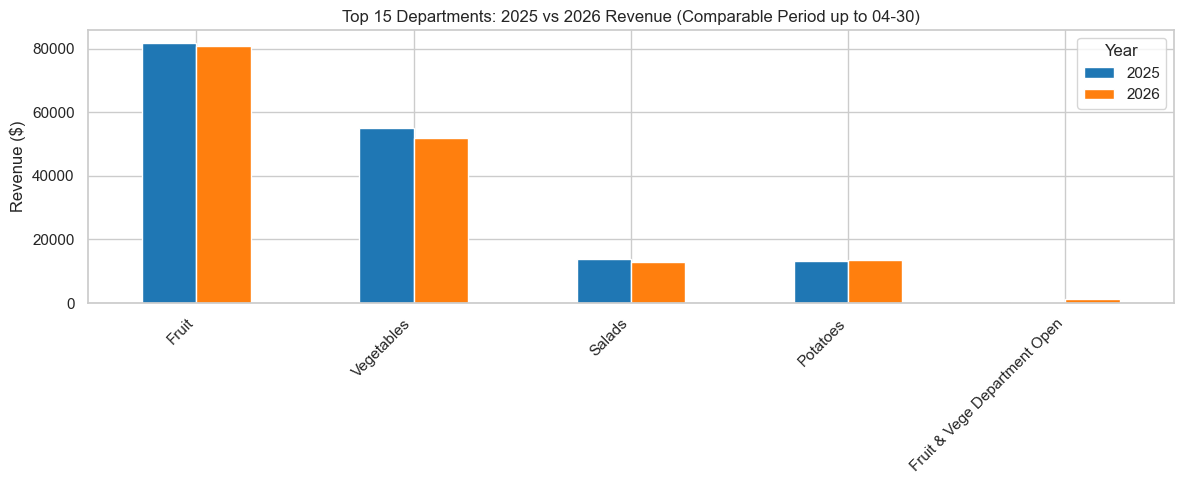

In [50]:
dept_yoy = comparable_sales.pivot_table(
    index="Sub Department Name", 
    columns="year", 
    values="Sales Ex GST", 
    aggfunc="sum"
).fillna(0)

# Sort by total revenue across both years to get the biggest departments first
dept_yoy['Total'] = dept_yoy.sum(axis=1)
dept_yoy = dept_yoy.sort_values('Total', ascending=False).drop(columns='Total').head(15)

dept_yoy.plot(kind="bar", figsize=(12, 5), color=['#1f77b4', '#ff7f0e'])
plt.title(f"Top 15 Departments: 2025 vs 2026 Revenue (Comparable Period up to {max_mm_dd_2025})")
plt.ylabel("Revenue ($)")
plt.xlabel("")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Year")
plt.tight_layout()
plt.show()

### Daily Sales Over Time (Overlapped for direct comparison)

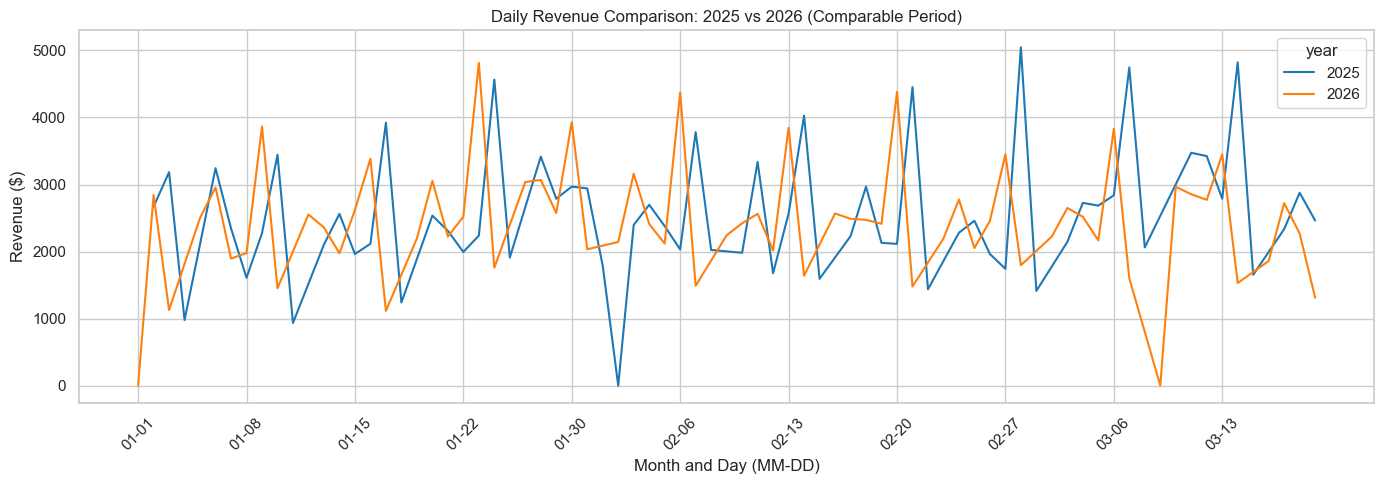

In [51]:
daily_yoy = comparable_sales.groupby(['mm_dd', 'year'])['Sales Ex GST'].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=daily_yoy, x='mm_dd', y='Sales Ex GST', hue='year', palette=['#1f77b4', '#ff7f0e'], linewidth=1.5)
plt.title(f"Daily Revenue Comparison: 2025 vs 2026 (Comparable Period)")
plt.xlabel("Month and Day (MM-DD)")
plt.ylabel("Revenue ($)")

# Clean up x-axis ticks so they are readable (show roughly every 7-10 days)
ticks = plt.gca().get_xticks()
plt.xticks(ticks[::7], rotation=45) 
plt.tight_layout()
plt.show()

### Top Items Comparison (by Register Scans / 'Lines')

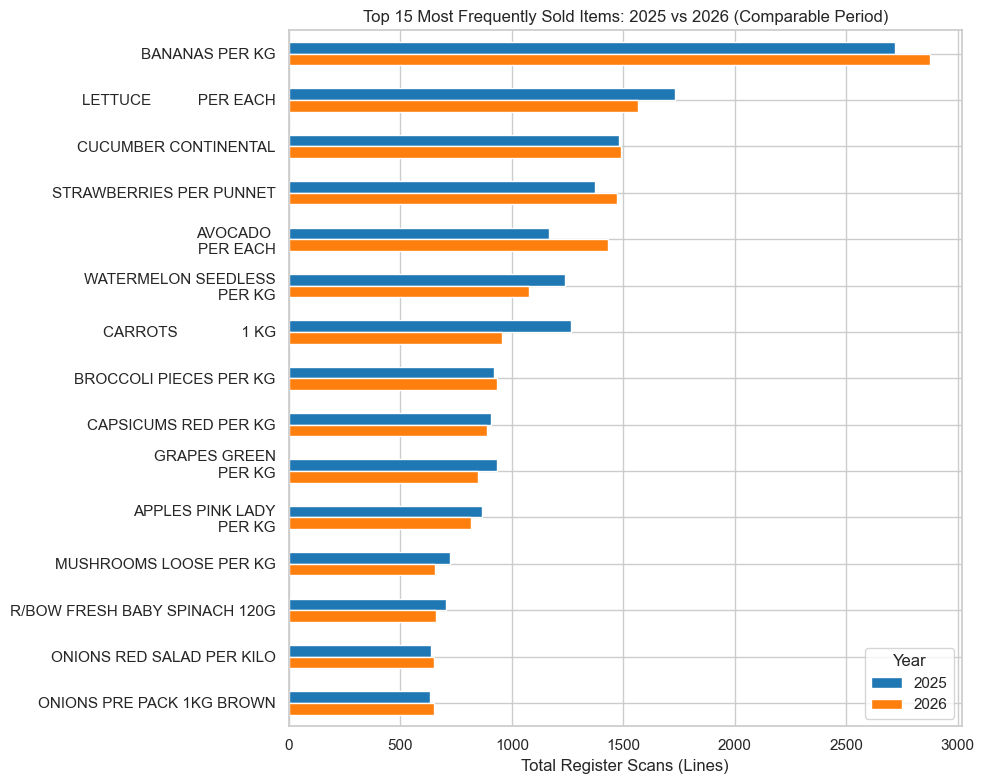

In [52]:
items_yoy = comparable_sales.pivot_table(
    index="Name", 
    columns="year", 
    values="Lines", 
    aggfunc="sum"
).fillna(0)

items_yoy['Total'] = items_yoy.sum(axis=1)
top_items = items_yoy.sort_values('Total', ascending=False).drop(columns='Total').head(15)

top_items.plot(kind="barh", figsize=(10, 8), color=['#1f77b4', '#ff7f0e'])
plt.title("Top 15 Most Frequently Sold Items: 2025 vs 2026 (Comparable Period)")
plt.xlabel("Total Register Scans (Lines)")
plt.ylabel("")
plt.gca().invert_yaxis() # Puts the #1 seller at the top
plt.legend(title="Year")
plt.tight_layout()
plt.show()

### Biggest Gross Profit (Total GP $) YoY

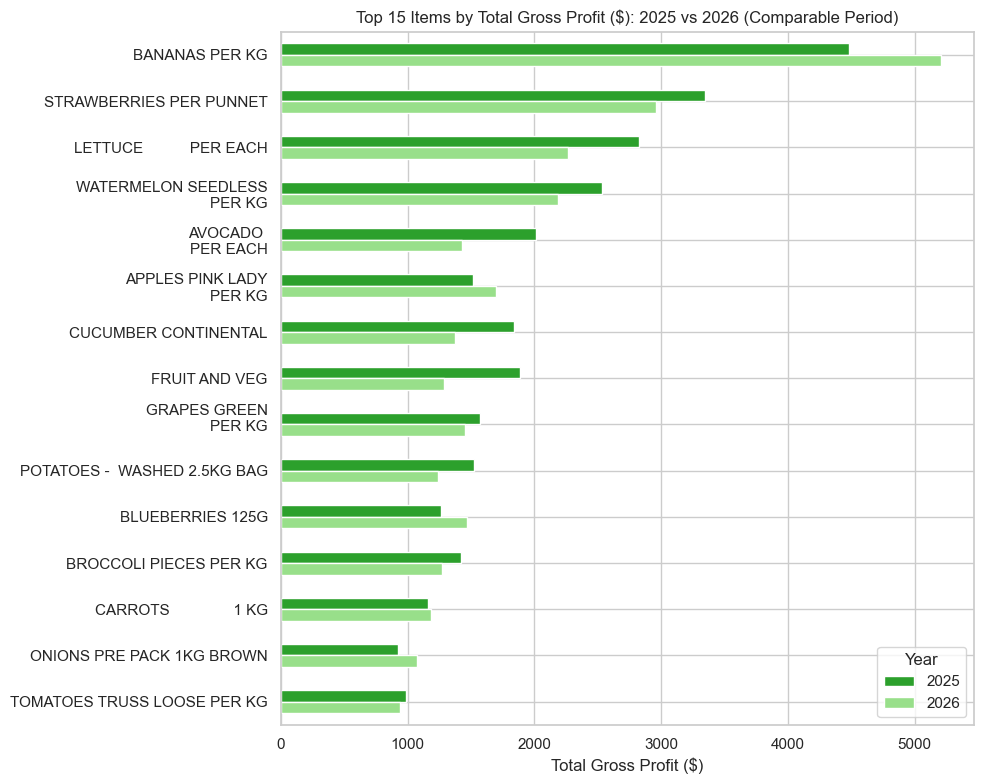

In [53]:
items_yoy_gp = comparable_sales.pivot_table(
    index="Name", 
    columns="year", 
    values="GP $", 
    aggfunc="sum"
).fillna(0)

items_yoy_gp['Total'] = items_yoy_gp.sum(axis=1)
top_items_gp = items_yoy_gp.sort_values('Total', ascending=False).drop(columns='Total').head(15)

top_items_gp.plot(kind="barh", figsize=(10, 8), color=['#2ca02c', '#98df8a'])
plt.title("Top 15 Items by Total Gross Profit ($): 2025 vs 2026 (Comparable Period)")
plt.xlabel("Total Gross Profit ($)")
plt.ylabel("")
plt.gca().invert_yaxis() # Puts the #1 most profitable at the top
plt.legend(title="Year")
plt.tight_layout()
plt.show()

### Most Profitable by Margin (GP %) YoY

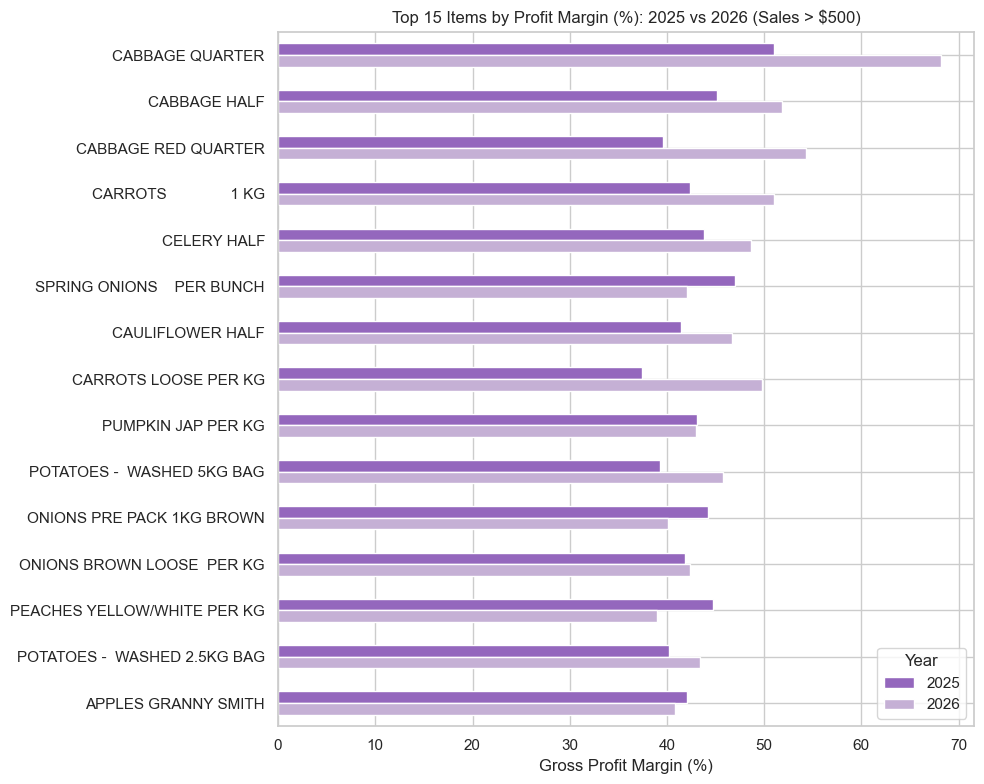

In [70]:
# --- MICRO-ANALYSIS FILTER ---
# Exclude generic Open Department rings and Dummy Items to prevent margin skew
clean_sales = comparable_sales[
    ~(comparable_sales['Sub Department Name'].str.contains('Open', case=False, na=False)) & 
    ~(comparable_sales['Name'].str.strip().str.upper() == 'FRUIT AND VEG')
].copy()

# Calculate total sales and profit per item to find the true weighted margin
item_margins = clean_sales.groupby(['Name', 'year']).agg(
    total_sales=('Sales Ex GST', 'sum'),
    total_gp=('GP $', 'sum')
).reset_index()

# FILTER: Only look at items that generated at least $500 in sales over the period 
# This removes "noisy" items that sold once for a 99% margin and skew the data
valid_items = item_margins.groupby('Name')['total_sales'].sum()
valid_items = valid_items[valid_items > 500].index
item_margins = item_margins[item_margins['Name'].isin(valid_items)]

# Calculate true Margin %
item_margins['Margin %'] = (item_margins['total_gp'] / item_margins['total_sales']) * 100

# Pivot for visualization
margin_yoy = item_margins.pivot(index="Name", columns="year", values="Margin %").fillna(0)

# Sort by the average margin across both years
margin_yoy['Avg_Margin'] = margin_yoy.mean(axis=1)
top_margin_items = margin_yoy.sort_values('Avg_Margin', ascending=False).drop(columns='Avg_Margin').head(15)

# Plotting
top_margin_items.plot(kind="barh", figsize=(10, 8), color=['#9467bd', '#c5b0d5'])
plt.title("Top 15 Items by Profit Margin (%): 2025 vs 2026 (Sales > $500)")
plt.xlabel("Gross Profit Margin (%)")
plt.ylabel("")
plt.gca().invert_yaxis()
plt.legend(title="Year")
plt.tight_layout()
plt.show()

### Deep Dive: The "Open Ring" Anomaly (FRUIT AND VEG)

**What this does:** Isolates the generic "FRUIT AND VEG" item and the "Fruit & Vege Department Open" sub-department. It tracks the exact dates this item was active, how much total revenue was pushed through it, and its average price point to figure out how cashiers were using it. 

**How to interpret:** * **The Timeline:** Look at the "Last Sale Date" and the monthly breakdown. You will likely see this item abruptly drop to zero on a specific date, marking the exact day the store changed its checkout system or banned cashiers from using the generic button.
* **The Financial Impact:** If this generic item accounts for a massive percentage of 2025's revenue, it means your 2025 data isn't missing—it's just "hidden" inside this one giant bucket. If you want to do a true product-by-product comparison (e.g., how many bananas you sold), you might need to exclude this item entirely so it doesn't skew your charts.

### Isolate the suspected Open/Dummy items and departments

In [62]:
open_item_mask = (sales_fruit['Name'] == 'FRUIT AND VEG') | (sales_fruit['Sub Department Name'] == 'Fruit & Vege Department Open')
open_data = sales_fruit[open_item_mask].copy()

print(f"🔍 Found {len(open_data)} total transactions logged under 'FRUIT AND VEG' or the 'Open' department.\n")

if len(open_data) > 0:
    # 2. Check the timeline of when this was actually used
    timeline = open_data.groupby('year')['Date'].agg(['min', 'max', 'count'])
    timeline.columns = ['First Appearance', 'Last Appearance', 'Total Transactions']
    timeline['First Appearance'] = timeline['First Appearance'].dt.date
    timeline['Last Appearance'] = timeline['Last Appearance'].dt.date
    
    print("--- 📅 Usage Timeline ---")
    display(timeline)
    
    # 3. Check the financial weight of this dummy item
    financials = open_data.groupby('year').agg(
        total_revenue=('Sales Ex GST', 'sum'),
        total_quantity=('Quantity', 'sum'),
        total_gp=('GP $', 'sum')
    )
    
    # Calculate what percentage of the STORE'S total revenue went through this single generic button
    store_totals = sales_fruit.groupby('year')['Sales Ex GST'].sum()
    financials['% of Entire Store Revenue'] = (financials['total_revenue'] / store_totals) * 100
    
    print("\n--- 💰 Financial Impact ---")
    display(financials.round(2))
    
    # 4. Monthly Breakdown to pinpoint the phase-out
    print("\n--- 📉 Monthly Phase-Out Tracker ---")
    monthly_usage = open_data.groupby(['year', 'year_month']).agg(
        transactions=('Name', 'count'),
        revenue=('Sales Ex GST', 'sum')
    ).unstack('year').fillna(0)
    display(monthly_usage.round(0))

🔍 Found 220 total transactions logged under 'FRUIT AND VEG' or the 'Open' department.

--- 📅 Usage Timeline ---


,First Appearance,Last Appearance,Total Transactions
year,,,
2025,2025-01-02,2025-04-26,109
2026,2026-01-05,2026-03-19,111



--- 💰 Financial Impact ---


,total_revenue,total_quantity,total_gp,% of Entire Store Revenue
year,,,,
2025,3041.83,305.41,2718.33,1.20
2026,2535.34,391.84,1443.94,1.57



--- 📉 Monthly Phase-Out Tracker ---


transactions       revenue        
year               2025  2026    2025    2026
year_month                                   
2025-01            32.0   0.0  1070.0     0.0
2025-02            26.0   0.0   472.0     0.0
2025-03            28.0   0.0   826.0     0.0
2025-04            23.0   0.0   674.0     0.0
2026-01             0.0  41.0     0.0  1010.0
2026-02             0.0  42.0     0.0   933.0
2026-03             0.0  28.0     0.0   592.0

## Overall Department Margin % (The Big Picture)

**What this does:** Validates the visual trend we spotted in the charts by calculating the exact, overall Profit Margin (%) for the entire Fruit and Veg department across both years during our comparable time period. 

**How to interpret:** If the 2026 percentage is higher than 2025, it confirms that while total sales volume dropped, the store became more profitable *per dollar earned* due to higher markups or lower supplier costs.

In [55]:
# Calculate the overall total revenue and profit for both years
overall_margin = comparable_sales.groupby('year').agg(
    total_revenue=('Sales Ex GST', 'sum'),
    total_profit=('GP $', 'sum')
)

# Calculate the true margin percentage
overall_margin['Overall Margin %'] = (overall_margin['total_profit'] / overall_margin['total_revenue']) * 100

print("--- Overall Department Profit Margin (Comparable Period) ---")
display(overall_margin[['Overall Margin %']].round(2))

# Calculate the exact difference
margin_diff = overall_margin.loc[2026, 'Overall Margin %'] - overall_margin.loc[2025, 'Overall Margin %']
trend = "UP" if margin_diff > 0 else "DOWN"

print(f"💡 Insight: The overall profit margin is {trend} by {abs(margin_diff):.2f} percentage points in 2026 compared to 2025.")

--- Overall Department Profit Margin (Comparable Period) ---


,Overall Margin %
year,
2025,37.97
2026,37.83


💡 Insight: The overall profit margin is DOWN by 0.14 percentage points in 2026 compared to 2025.


## Profitability Shifts & Price Elasticity (Advanced)

**What this does:** As an expert next step, this cell goes beyond surface-level averages to calculate true economic metrics. 
1. **YoY Profitability Matrix:** It calculates both the *Total GP $* and the *Margin %* by sub-department for both years. This reveals if a department is becoming more efficient (higher margin) but losing actual cash (lower total GP).
2. **Weighted Price Changes:** Instead of a simple average, it calculates the **Volume-Weighted Average Price** (`Total Revenue / Total Quantity`). This is the most accurate way to measure what customers actually paid over the year.
3. **Price Elasticity of Demand (PED):** It calculates the standard economic metric for elasticity (`% Change in Volume / % Change in Price`). It plots this on a scatter chart where the *size of the bubble* represents the item's total revenue, showing you exactly which critical items are most sensitive to price hikes.

**How to interpret:** * **GP Matrix:** Look for "Danger Zones"—departments where Margin % went UP, but Total GP $ went DOWN. This means price hikes worked mathematically, but alienated too many customers and cost you actual dollars.
* **Elasticity (PED) Score:** * **If PED < -1.0:** The item is *Highly Elastic*. A 10% price increase caused *more* than a 10% drop in sales. (Action: Lower the price to win back volume).
    * **If PED is between 0 and -1.0:** The item is *Inelastic*. Customers bought slightly less, but you still made more money overall from the price hike. (Action: Safe to keep prices high).
* **The Scatter Plot:** You want your biggest bubbles (top revenue generators) to be on the right side (price increases) but *above* the horizontal zero-line (meaning volume didn't drop). If massive bubbles are in the bottom-right quadrant, your core business is bleeding volume due to pricing.

In [64]:
import warnings
warnings.filterwarnings('ignore')

# Safely filter out clearance items to avoid distorting our base price elasticity
clean_sales = comparable_sales[
    (~comparable_sales['Name'].str.contains('REDUCED|CLEARANCE|MARKDOWN', case=False, na=False)) & 
    (comparable_sales['Quantity'] > 0)
].copy()

# --- 1. The Profitability Matrix (GP $ vs Margin %) ---
print("--- 1. Sub-Department Profitability Matrix (YoY) ---")
dept_matrix = clean_sales.groupby(['Sub Department Name', 'year']).agg(
    total_sales=('Sales Ex GST', 'sum'),
    total_gp=('GP $', 'sum')
)
dept_matrix['Margin %'] = (dept_matrix['total_gp'] / dept_matrix['total_sales']) * 100
dept_matrix = dept_matrix.unstack('year').fillna(0)

# Calculate YoY Differences (using proper MultiIndex referencing)
dept_matrix[('GP $ Change', '')] = dept_matrix[('total_gp', 2026)] - dept_matrix[('total_gp', 2025)]
dept_matrix[('Margin % Change', '')] = dept_matrix[('Margin %', 2026)] - dept_matrix[('Margin %', 2025)]

# Sort by who lost or gained the most actual dollars
cols_to_show = [('total_gp', 2025), ('total_gp', 2026), ('GP $ Change', ''), ('Margin %', 2025), ('Margin %', 2026), ('Margin % Change', '')]
display(dept_matrix[cols_to_show].sort_values(by=('GP $ Change', ''), ascending=True).round(2))

--- 1. Sub-Department Profitability Matrix (YoY) ---


total_gp           GP $ Change Margin %         \
year                              2025      2026                 2025   2026   
Sub Department Name                                                            
Vegetables                    21650.35  20570.56    -1079.79    39.35  39.71   
Fruit                         30185.34  29885.75     -299.60    36.93  36.97   
Salads                         4290.00   4078.37     -211.63    30.91  31.39   
Fruit & Vege Department Open      0.00     37.12       37.12     0.00  35.73   
Potatoes                       4941.14   5141.96      200.82    37.69  38.40   

                             Margin % Change  
year                                          
Sub Department Name                           
Vegetables                              0.36  
Fruit                                   0.04  
Salads                                  0.48  
Fruit & Vege Department Open           35.73  
Potatoes                                0.71

### True Weighted Price Changes & Volume Impact

In [65]:
print("\n--- 2. Price Elasticity of Demand (Top 20 Sellers) ---")
top_20 = clean_sales.groupby('Name')['Quantity'].sum().nlargest(20).index

# Calculate Volume and Weighted Average Price (Total Revenue / Total Quantity)
elasticity_data = clean_sales[clean_sales['Name'].isin(top_20)].groupby(['Name', 'year']).agg(
    total_sales=('Sales Ex GST', 'sum'),
    total_volume=('Quantity', 'sum')
)
elasticity_data['weighted_price'] = elasticity_data['total_sales'] / elasticity_data['total_volume']
elasticity_data = elasticity_data.unstack('year').dropna()

# Calculate % Changes
p_change = (elasticity_data[('weighted_price', 2026)] / elasticity_data[('weighted_price', 2025)] - 1) * 100
v_change = (elasticity_data[('total_volume', 2026)] / elasticity_data[('total_volume', 2025)] - 1) * 100

ped_df = pd.DataFrame({
    '2025 Price ($)': elasticity_data[('weighted_price', 2025)],
    '2026 Price ($)': elasticity_data[('weighted_price', 2026)],
    'Price Change (%)': p_change,
    'Volume Change (%)': v_change,
    'Total 2026 Revenue': elasticity_data[('total_sales', 2026)] # Used for bubble size
}).round(2)

# Calculate PED (Price Elasticity of Demand)
ped_df['PED Score'] = np.where(ped_df['Price Change (%)'] != 0, 
                               ped_df['Volume Change (%)'] / ped_df['Price Change (%)'], 
                               0).round(2)

display(ped_df.sort_values('Volume Change (%)', ascending=True))


--- 2. Price Elasticity of Demand (Top 20 Sellers) ---


,2025 Price ($),2026 Price ($),Price Change (%),Volume Change (%),Total 2026 Revenue,PED Score
Name,,,,,,
TOMATOES -\n CHERRY PUNNET 250G,3.74,2.96,-20.85,-39.27,1029.03,1.88
CARROTS 1 KG,2.16,2.43,12.71,-24.57,2323.56,-1.93
CUCUMBER BABY LEBANESE P/PACK 250GMS,3.79,3.89,2.69,-22.57,2014.35,-8.39
POTATOES - WASHED 2.5KG BAG,7.09,6.74,-4.83,-20.90,2859.25,4.33
BLUEBERRIES 125G,5.90,6.78,15.02,-14.78,3871.89,-0.98
LETTUCE PER EACH,4.22,3.60,-14.61,-9.42,5648.90,0.64
WATERMELON SEEDLESS\nPER KG,2.47,2.45,-0.78,-9.38,5623.01,12.03
GRAPES DARK\nPER KG,5.67,5.12,-9.70,-8.83,2165.06,0.91
GRAPES GREEN\nPER KG\n,5.99,6.24,4.10,-7.96,4932.38,-1.94


### --- Advanced Correlation Bubble Chart ---


Overall Correlation between Price Hikes and Volume Drops: -0.40


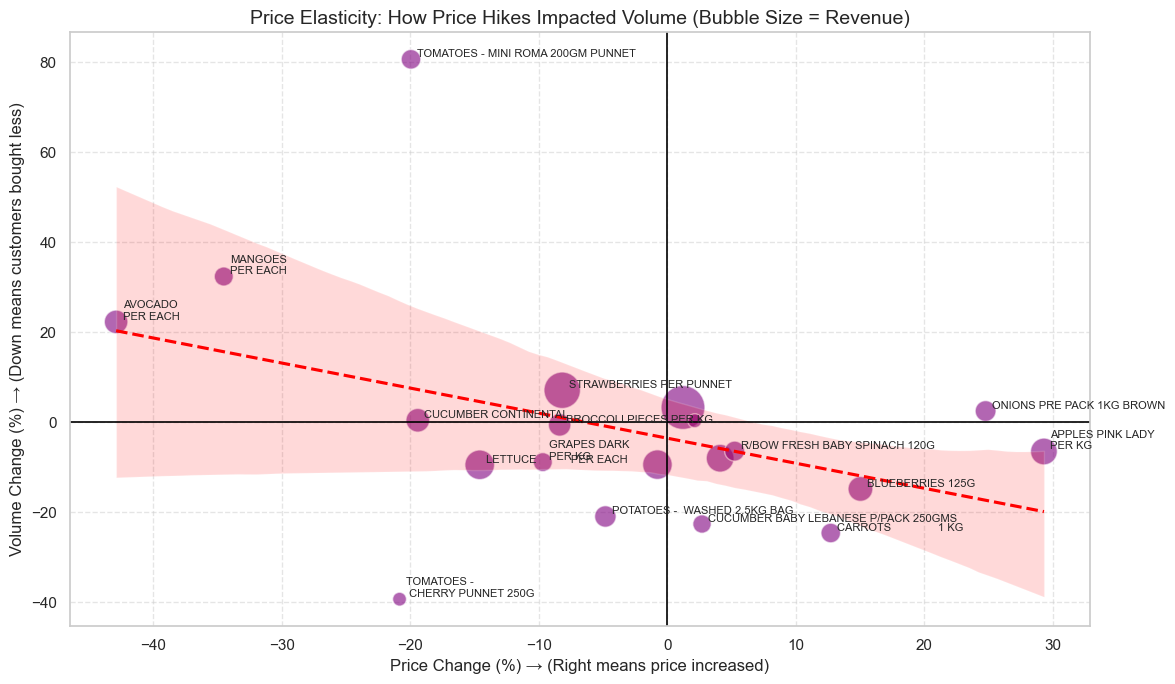

In [58]:
correlation = ped_df['Price Change (%)'].corr(ped_df['Volume Change (%)'])
print(f"\nOverall Correlation between Price Hikes and Volume Drops: {correlation:.2f}")

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=ped_df, 
    x='Price Change (%)', 
    y='Volume Change (%)', 
    size='Total 2026 Revenue', # Bubble size represents revenue importance
    sizes=(100, 1000), 
    alpha=0.6,
    color='purple',
    legend=False
)

# Add line of best fit
sns.regplot(
    data=ped_df, x='Price Change (%)', y='Volume Change (%)', 
    scatter=False, color='red', line_kws={'linestyle':'--'}
)

# Annotate the bubbles with the item names
for i, row in ped_df.iterrows():
    # Only label extreme movers to avoid clutter
    if abs(row['Price Change (%)']) > 5 or abs(row['Volume Change (%)']) > 10:
        plt.text(row['Price Change (%)'] + 0.5, row['Volume Change (%)'] + 0.5, i, fontsize=8)

plt.axhline(0, color='black', linewidth=1.2)
plt.axvline(0, color='black', linewidth=1.2)
plt.title("Price Elasticity: How Price Hikes Impacted Volume (Bubble Size = Revenue)", fontsize=14)
plt.xlabel("Price Change (%) → (Right means price increased)")
plt.ylabel("Volume Change (%) → (Down means customers bought less)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Actionable Insights: The "Margin Trap" Target List

**What this does:** This cell takes the elasticity data from the previous step and turns it into a targeted action plan. It specifically filters your top items to find the "Margin Trap" culprits: products where you raised the price, customers bought less, and as a direct result, you made *less total profit dollars* than last year. 

**How to interpret:** This is your immediate "Price Reduction Hitlist." The table is sorted by the `GP $ Lost` column, putting the biggest financial bleeders at the very top. If an item is on this list, your price hike failed financially. Lowering the retail price of these specific items back toward their 2025 levels is the fastest way to win back customer volume and recover those lost profit dollars.

### Calculate the actual Profit Dollars (GP $) lost per item

In [66]:
item_gp = clean_sales.groupby(['Name', 'year'])['GP $'].sum().unstack('year').dropna()

# Calculate the exact dollar difference between the two years
item_gp['GP $ Difference'] = item_gp[2026] - item_gp[2025]

# 2. Combine this with our elasticity data (ped_df) from Cell 14
# We join the data so we can see Price, Volume, and Profit all in one place
target_list = ped_df.join(item_gp[['GP $ Difference']])

# 3. Filter for the "Margin Trap" conditions:
# Condition A: Price went UP (> 0)
# Condition B: Volume went DOWN (< 0)
# Condition C: Total Profit Dollars went DOWN (< 0)
action_list = target_list[
    (target_list['Price Change (%)'] > 0) & 
    (target_list['Volume Change (%)'] < 0) & 
    (target_list['GP $ Difference'] < 0)
].copy()

# Sort the list so the items that lost the most money appear at the top
action_list = action_list.sort_values('GP $ Difference', ascending=True)

print(f"🚨 ACTION REQUIRED: Found {len(action_list)} top items stuck in the 'Margin Trap'.")
print("These items lost total profit dollars specifically because their price was raised too high.\n")

# Clean up the display columns for the final report
cols_to_display = ['2025 Price ($)', '2026 Price ($)', 'Price Change (%)', 'Volume Change (%)', 'GP $ Difference']
display(action_list[cols_to_display].round(2))

# Calculate the total cash bleeding from just these items
total_lost = action_list['GP $ Difference'].sum()
print(f"\n📉 Total Gross Profit lost across these {len(action_list)} items: ${abs(total_lost):,.2f}")
print("Recommendation: Consider rolling back prices on the top 3-5 items on this list to stimulate volume.")

🚨 ACTION REQUIRED: Found 2 top items stuck in the 'Margin Trap'.
These items lost total profit dollars specifically because their price was raised too high.



,2025 Price ($),2026 Price ($),Price Change (%),Volume Change (%),GP $ Difference
Name,,,,,
GRAPES GREEN\nPER KG\n,5.99,6.24,4.10,-7.96,-115.35
CUCUMBER BABY LEBANESE P/PACK 250GMS,3.79,3.89,2.69,-22.57,-36.12



📉 Total Gross Profit lost across these 2 items: $151.47
Recommendation: Consider rolling back prices on the top 3-5 items on this list to stimulate volume.
